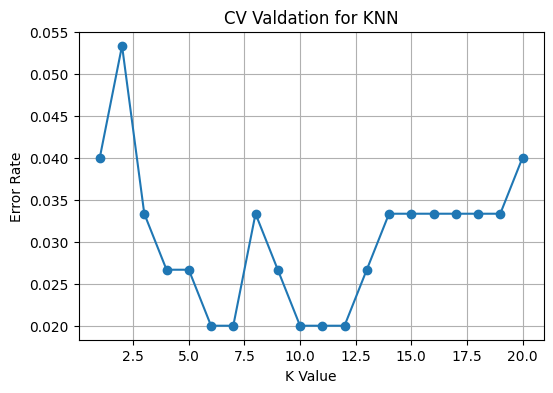

Test Accuracy: 1.0
Cross-validation scores: [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
Mean CV Accuracy: 0.9666666666666668


In [ ]:
# Import libraries
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Load Iris dataset from seaborn
iris = sns.load_dataset("iris")

# Features and target
X = iris.drop("species", axis=1)
y = iris["species"]

# Convert labels to numbers
le = LabelEncoder()
y = le.fit_transform(y)


# -------------------------------
#  Method (Choosing Best K)
# -------------------------------
error_rates = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=5)
    error_rates.append(1 - scores.mean())

# Plot
plt.figure(figsize=(6, 4))
plt.plot(range(1, 21), error_rates, marker="o")
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.title("CV Valdation for KNN")
plt.grid(True)
plt.show()

# -------------------------------
# Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train KNN with chosen K (example: 3)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict
y_pred = knn.predict(X_test)

# Accuracy
print("Test Accuracy:", accuracy_score(y_test, y_pred))

# -------------------------------
# 5-Fold Cross Validation
# -------------------------------
cv_scores = cross_val_score(knn, X, y, cv=5)

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

In [ ]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [ ]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

cv_scores = cross_val_score(knn, X, y, cv=5)
print("Mean CV Accuracy:", cv_scores.mean())

Test Accuracy: 0.9666666666666667
Mean CV Accuracy: 0.9800000000000001


Enter Sepal Length: 2
Enter Sepal Width: 1.7
Enter Petal Length: 3
Enter Petal Width: 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Predicted Species: versicolor


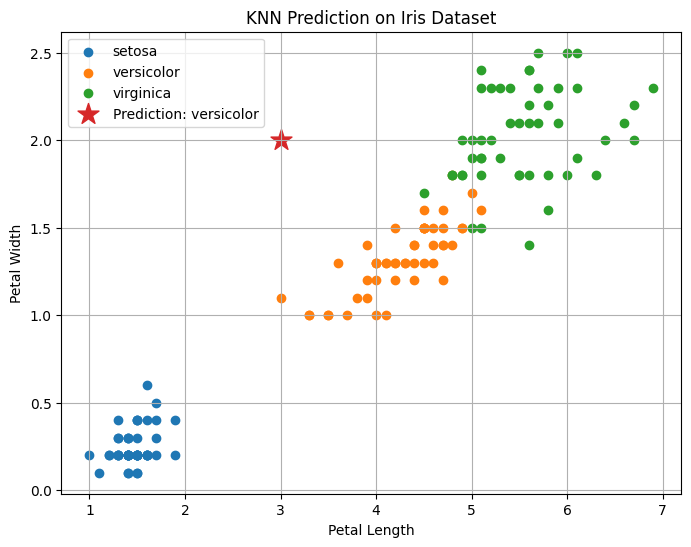

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

# Load Iris dataset
iris = sns.load_dataset("iris")

# Features and target
X = iris.drop("species", axis=1)
y = iris["species"]

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y)

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X, y)

# -----------------------------
# Take input from the user
# -----------------------------
sepal_length = float(input("Enter Sepal Length: "))
sepal_width = float(input("Enter Sepal Width: "))
petal_length = float(input("Enter Petal Length: "))
petal_width = float(input("Enter Petal Width: "))

new_flower = [[
    sepal_length,
    sepal_width,
    petal_length,
    petal_width
]]

# Predict
prediction = knn.predict(new_flower)[0]
species = le.inverse_transform([prediction])[0]

print("Predicted Species:", species)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 6))

# Plot existing data (Petal Length vs Petal Width)
for sp in iris["species"].unique():
    subset = iris[iris["species"] == sp]
    plt.scatter(
        subset["petal_length"],
        subset["petal_width"],
        label=sp
    )

# Plot the user's point
plt.scatter(
    petal_length,
    petal_width,
    marker="*",
    s=250,
    label=f"Prediction: {species}"
)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("KNN Prediction on Iris Dataset")
plt.legend()
plt.grid(True)
plt.show()

Best K: 6
Best Cross Validation Accuracy: 0.9800000000000001


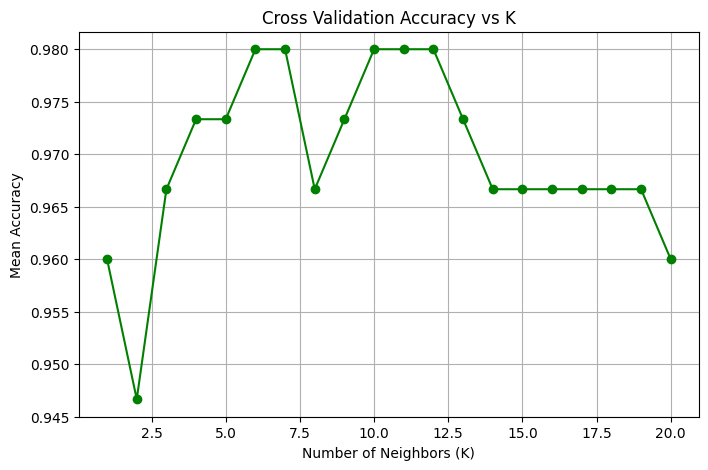

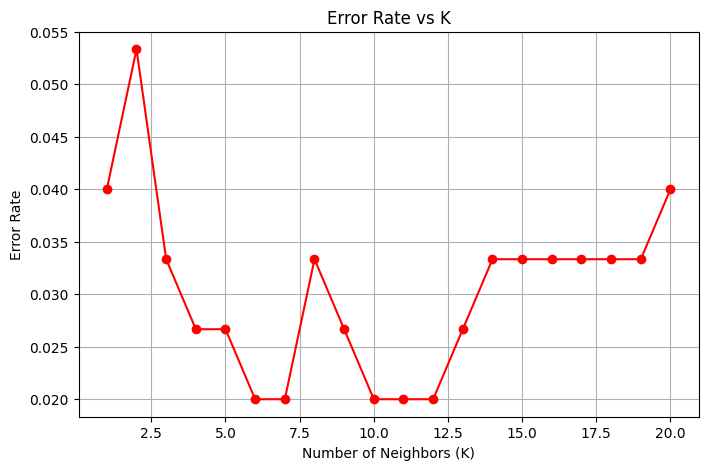


Test Accuracy:
1.0

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


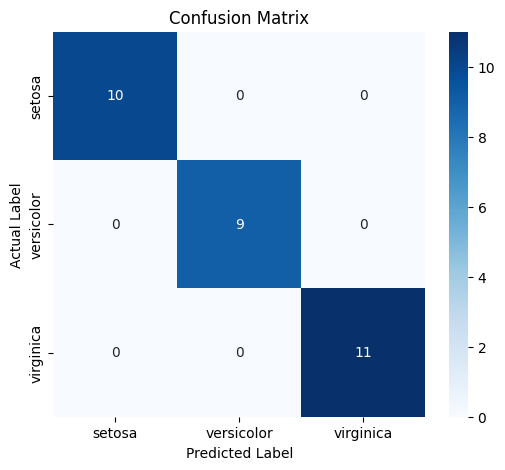

In [ ]:
# =====================================
# KNN with Cross Validation (Complete)
# =====================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# -------------------------
# Load Dataset
# -------------------------
iris = sns.load_dataset("iris")

X = iris.drop("species", axis=1)
y = iris["species"]

# Convert labels to numbers
le = LabelEncoder()
y = le.fit_transform(y)

# -------------------------
# Find Best K using Cross Validation
# -------------------------
k_values = range(1, 21)

cv_accuracy = []
error_rate = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X,
        y,
        cv=5,
        scoring="accuracy"
    )

    cv_accuracy.append(scores.mean())
    error_rate.append(1 - scores.mean())

best_k = k_values[np.argmax(cv_accuracy)]

print("="*40)
print("Best K:", best_k)
print("Best Cross Validation Accuracy:", max(cv_accuracy))
print("="*40)

# -------------------------
# Plot Accuracy vs K
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_accuracy, marker='o', color='green')
plt.title("Cross Validation Accuracy vs K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean Accuracy")
plt.grid(True)
plt.show()

# -------------------------
# Plot Error Rate vs K
# -------------------------
plt.figure(figsize=(8,5))
plt.plot(k_values, error_rate, marker='o', color='red')
plt.title("Error Rate vs K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Error Rate")
plt.grid(True)
plt.show()

# -------------------------
# Train-Test Split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -------------------------
# Train Final Model
# -------------------------
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

# -------------------------
# Prediction
# -------------------------
y_pred = knn.predict(X_test)

# -------------------------
# Accuracy
# -------------------------
print("\nTest Accuracy:")
print(accuracy_score(y_test, y_pred))

# -------------------------
# Classification Report
# -------------------------
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

# -------------------------
# Confusion Matrix
# -------------------------
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# -------------------------
# Heatmap
# -------------------------
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [1]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# from sklearn.cluster import KMeans

# # Load dataset
# iris = sns.load_dataset("iris")

# # Features only (no labels)
# X = iris.drop("species", axis=1)

# # Elbow Method
# wcss = []

# for k in range(1, 11):
#     kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
#     kmeans.fit(X)
#     wcss.append(kmeans.inertia_)

# # Plot
# plt.figure(figsize=(7,5))
# plt.plot(range(1,11), wcss, marker='o')
# plt.xlabel("Number of Clusters (K)")
# plt.ylabel("WCSS")
# plt.title("Elbow Method for K-Means")
# plt.grid(True)
# plt.show()